<a href="https://colab.research.google.com/github/jupawest/SoSSProject/blob/main/voice_recognition_model4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
!pip install librosa numpy soundfile matplotlib scikit-learn fastdtw

import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from sklearn.mixture import GaussianMixture
from IPython.display import Javascript, display, Audio
from base64 import b64decode
import subprocess
from pathlib import Path
from google.colab import output, drive

# Mount Google Drive
drive.mount('/content/drive')
GMM_DIR = Path("/content/drive/MyDrive/voice-gmm")
DTW_DIR = Path("/content/drive/MyDrive/voice-dtw")
GMM_DIR.mkdir(exist_ok=True)
DTW_DIR.mkdir(exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
import csv
import datetime
LOG_PATH = "/content/drive/MyDrive/voice-auth-log.csv"

In [27]:
RECORD_JS = """
const sleep = t => new Promise(r=>setTimeout(r,t));
const readBlob = b=>new Promise(r=>{
  const fr = new FileReader();
  fr.onloadend = e => r(e.target.result);
  fr.readAsDataURL(b);
});
var record = t => new Promise(async r=>{
  const stream = await navigator.mediaDevices.getUserMedia({audio:true});
  const rec = new MediaRecorder(stream);
  const chunks = [];
  rec.ondataavailable = e => chunks.push(e.data);
  rec.start();
  await sleep(t);
  rec.stop();
  rec.onstop = async () => r(await readBlob(new Blob(chunks)));
});
"""

def record_audio(sec=3, raw_fn="raw.webm", wav_fn="input.wav"):
    display(Javascript(RECORD_JS))
    data = output.eval_js(f"record({sec*1000})")
    with open(raw_fn, 'wb') as f:
        f.write(b64decode(data.split(',')[1]))
    subprocess.run(['ffmpeg', '-y', '-i', raw_fn, '-ar', '16000', '-ac', '1', wav_fn],
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return wav_fn


In [28]:
def extract_mfcc(path, n_mfcc=13):
    data, sr = sf.read(path)
    if data.ndim > 1:
        data = np.mean(data, axis=1)
    return librosa.feature.mfcc(y=data, sr=sr, n_mfcc=n_mfcc).T

def plot_waveform_and_mfcc(path):
    y, sr = librosa.load(path, sr=16000)
    plt.figure(figsize=(10, 3))
    plt.title(f"Waveform of {Path(path).name}")
    librosa.display.waveshow(y, sr=sr)
    plt.tight_layout()
    plt.show()

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfccs, x_axis='time')
    plt.title('MFCC')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    display(Audio(path))

In [40]:
def enroll_user(user_name):
    wav_path = GMM_DIR / f"{user_name}.wav"
    print(f"🎙️ Recording for user: {user_name}")
    record_audio(sec=3, wav_fn=str(wav_path))
    subprocess.run(['cp', str(wav_path), str(DTW_DIR / wav_path.name)])
    print(f"✅ Enrolled {user_name} for both GMM and DTW")
    plot_waveform_and_mfcc(str(wav_path))


In [30]:
def train_gmm_models():
    models = {}
    for file in GMM_DIR.glob("*.wav"):
        mfcc_feat = extract_mfcc(str(file))
        gmm = GaussianMixture(n_components=8, covariance_type='diag', n_init=3)
        gmm.fit(mfcc_feat)
        models[file.stem] = gmm
        print(f"✅ Trained model for {file.stem}, avg log likelihood: {gmm.score(mfcc_feat):.2f}")
    return models


In [70]:
def authenticate_with_fallback(models, gmm_threshold=-100.0, dtw_threshold=200):
    print("\n📥 Recording your test voice...")
    test_path = record_audio(sec=3, wav_fn="test.wav")
    print(f"✅ Recorded test sample: {test_path}")
    plot_waveform_and_mfcc(test_path)
    test_mfcc = extract_mfcc(test_path)

    print("\n🔎 Comparing your voice to enrolled GMM models...")
    gmm_scores = {}
    for user, model in models.items():
        score = model.score(test_mfcc)
        gmm_scores[user] = score
        print(f"📂 Compared to: {user} (GMM model) — Log-likelihood score: {score:.2f}")

    best_user, best_score = max(gmm_scores.items(), key=lambda x: x[1])
    print(f"\n🏁 Best GMM Match: {best_user} with score {best_score:.2f}")

    if best_score >= gmm_threshold:
        print(f"✅ GMM says it's {best_user} — Access Granted")
        return

    print("\n⚠️ GMM score too low — Trying DTW as fallback...")

    dtw_distances = []
    for file in DTW_DIR.glob("*.wav"):
        user = file.stem
        print(f"🔄 Comparing to {user} (DTW file: {file.name})")
        enrolled = extract_mfcc(str(file))
        dist, _ = fastdtw(test_mfcc, enrolled, dist=euclidean)
        dtw_distances.append((user, dist))

    dtw_distances.sort(key=lambda x: x[1])
    best_dtw_user, best_dtw_dist = dtw_distances[0]

    print(f"\n🏁 Best DTW Match: {best_dtw_user} with distance {best_dtw_dist:.2f}")

    for user, dist in dtw_distances:
        status = "✅ Pass" if dist <= dtw_threshold else "❌ Fail"
        print(f"📂 {user} — DTW Distance: {dist:.2f} — {status}")

    if best_dtw_dist <= dtw_threshold:
        print(f"\n✅ DTW says it's {best_dtw_user} — Access Granted (Fallback)")
    else:
        print("\n❌ Access Denied — Your voice didn't match any known users")




🎙️ Recording for user: user1


<IPython.core.display.Javascript object>

✅ Enrolled user1 for both GMM and DTW


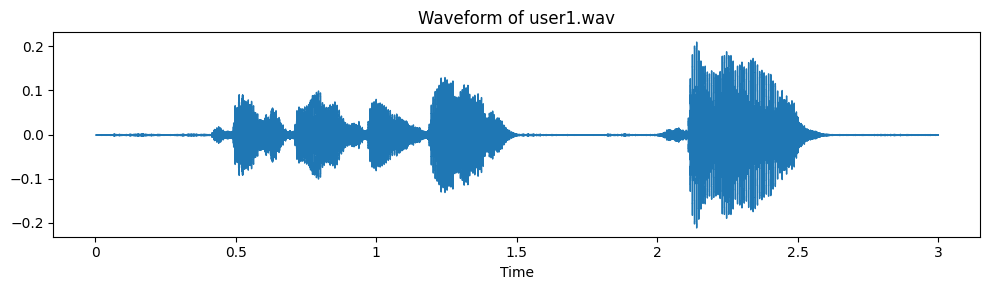

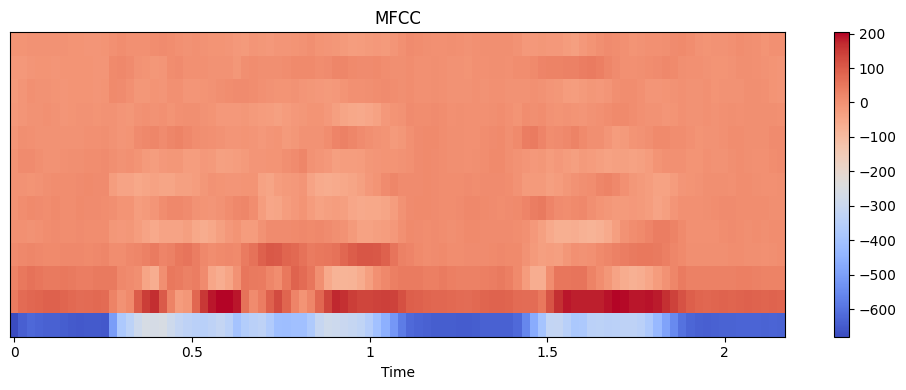

In [82]:
enroll_user("user1")

🎙️ Recording for user: user2


<IPython.core.display.Javascript object>

✅ Enrolled user2 for both GMM and DTW


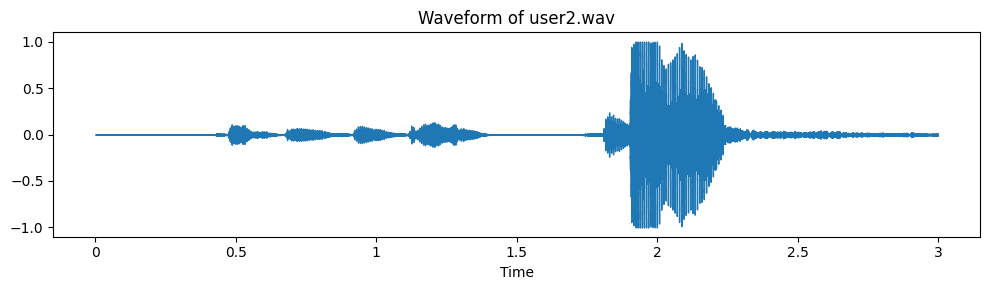

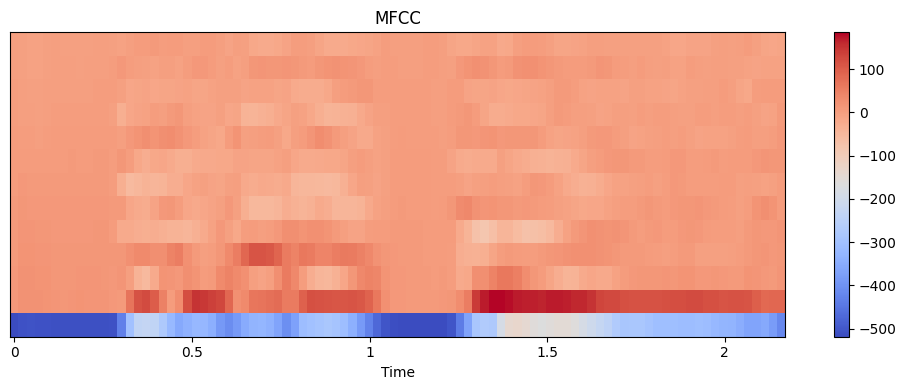

In [83]:
enroll_user("user2")


🎙️ Recording for user: user3


<IPython.core.display.Javascript object>

✅ Enrolled user3 for both GMM and DTW


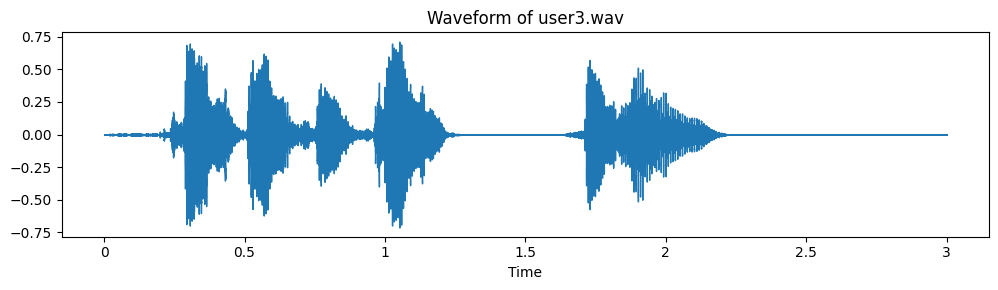

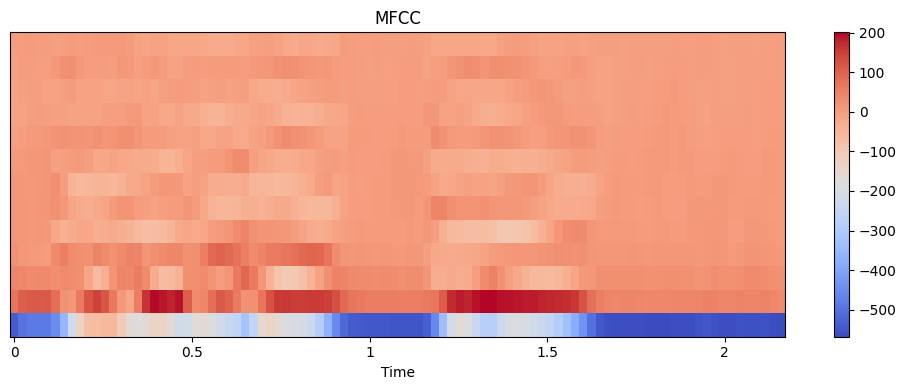

In [84]:
enroll_user("user3")

In [100]:
models = train_gmm_models()

✅ Trained model for test1, avg log likelihood: -49.34
✅ Trained model for test2, avg log likelihood: -48.03
✅ Trained model for user1, avg log likelihood: -48.71
✅ Trained model for user2, avg log likelihood: -45.96
✅ Trained model for user3, avg log likelihood: -47.68



📥 Recording your test voice...


<IPython.core.display.Javascript object>

✅ Recorded test sample: test.wav


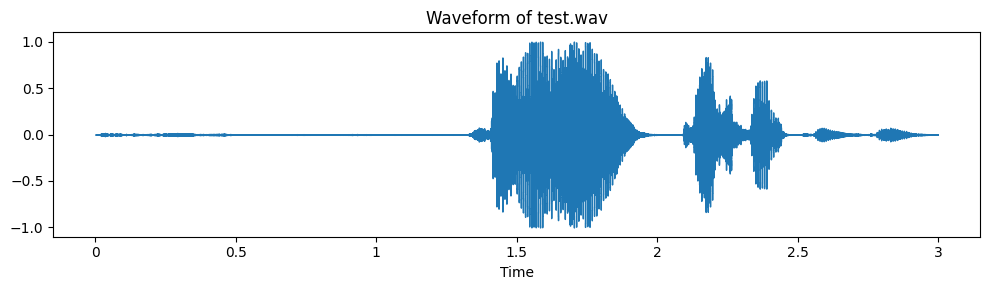

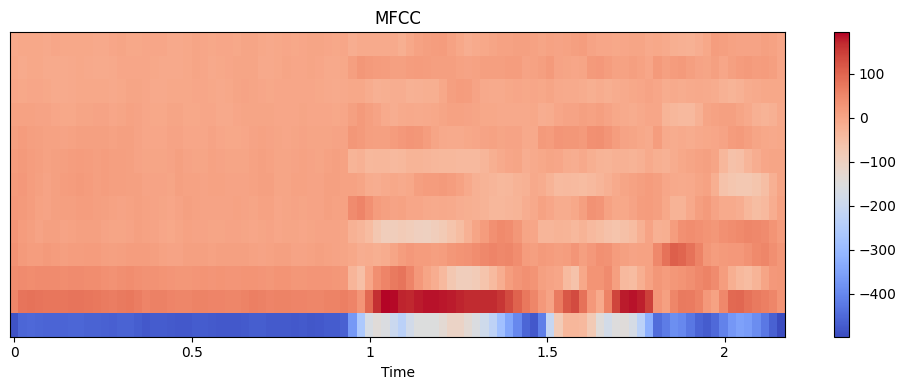


🔎 Comparing your voice to enrolled GMM models...
📂 Compared to: test1 (GMM model) — Log-likelihood score: -69.97
📂 Compared to: test2 (GMM model) — Log-likelihood score: -71.09
📂 Compared to: user1 (GMM model) — Log-likelihood score: -65.85
📂 Compared to: user2 (GMM model) — Log-likelihood score: -61.13
📂 Compared to: user3 (GMM model) — Log-likelihood score: -56.73

🏁 Best GMM Match: user3 with score -56.73
✅ GMM says it's user3 — Access Granted


In [86]:
authenticate_with_fallback(models)